In [1]:
import numpy as np
import pandas as pd
import qstudy as qs
from qstudy import Study
from qstudy.constants import SP500
import matplotlib.pyplot as plt

In [2]:
start_date = "2015-01-01"
end_date = "2023-12-31"
universe = qs.download(SP500, start_date, end_date)
factors = qs.download(
    ["SPY", "XLK"],
    start_date,
    end_date,
)
benchmark = qs.download("SPY", start_date, end_date)

$GEV: possibly delisted; no price data found  (1d 2015-01-01 -> 2023-12-31) (Yahoo error = "Data doesn't exist for startDate = 1420088400, endDate = 1703998800")
$SOLV: possibly delisted; no price data found  (1d 2015-01-01 -> 2023-12-31) (Yahoo error = "Data doesn't exist for startDate = 1420088400, endDate = 1703998800")

2 Failed downloads:
['GEV', 'SOLV']: possibly delisted; no price data found  (1d 2015-01-01 -> 2023-12-31) (Yahoo error = "Data doesn't exist for startDate = 1420088400, endDate = 1703998800")


In [3]:
returns_df = universe.returns
close_df = universe.close
volume_df = universe.volume
factor_returns = factors.returns
benchmark_returns = benchmark.returns

In [4]:
residuals_df, factor_params, factor_rsq = qs.residualize(returns_df, factor_returns)

manual signal sample (last date):
{'CB': -0.0004769278503193111, 'CME': -0.0007880165241894684, 'GE': -0.002900699408259367, 'GIS': 0.0005940250630160071, 'HD': 0.005366575286816703, 'HLT': 0.00033053069742914606, 'ICE': -0.0059907840359838555, 'KMB': -0.000638489049044911, 'LMT': -0.000124258205637155, 'LOW': 0.004153882495751666, 'MAR': -0.001419089025717386, 'PM': -0.000856506004398065, 'ROP': 0.00016022453923760654, 'SYK': -0.0032275321802684017, 'TJX': -0.0022129326693820757, 'TMUS': -0.001622661682587695, 'WELL': -0.0011303625623265334}
manual positions shape: (2264, 461)
manual positions columns with any nonzero: 353
sharpe                              1.100757
ann_return                          0.116674
ann_vol                             0.105297
max_drawdown                       -0.161168
max_drawdown_duration                    310
max_drawdown_start       2017-02-02 00:00:00
max_drawdown_end         2018-04-26 00:00:00
avg_daily_turnover                  0.169658
benchmar

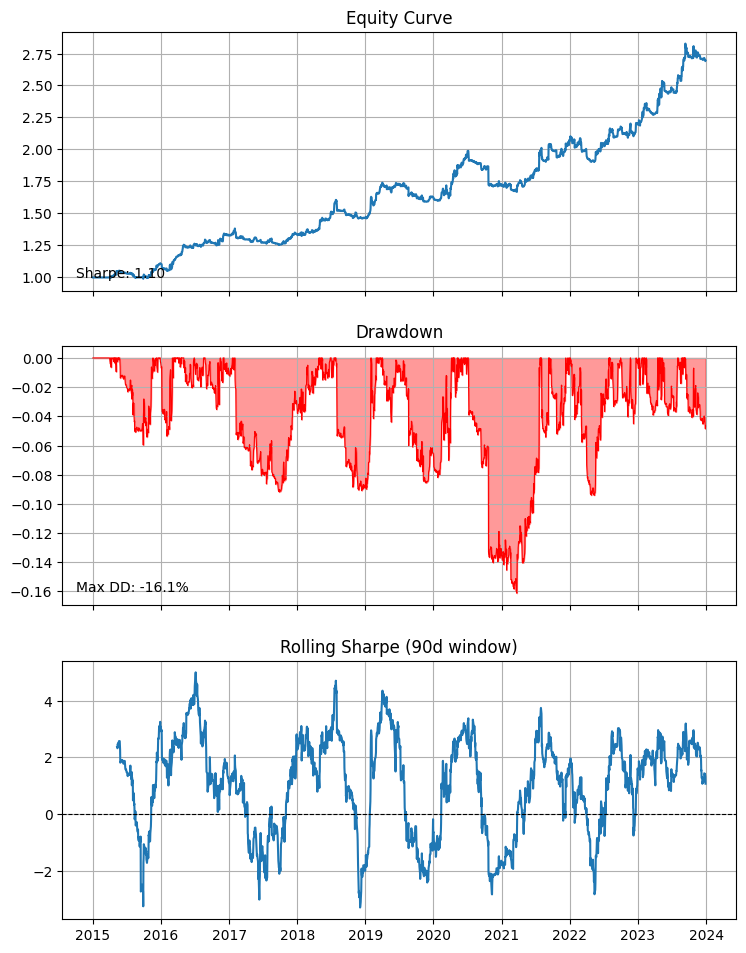

In [5]:
# -------------------------------------------------------------------
# residual mean reversion base signal
# -------------------------------------------------------------------

signal = -residuals_df.rolling(5).mean().shift(1)
signal = signal.sub(signal.mean(axis=1), axis=0)

# -------------------------------------------------------------------
# conditioning filters
# -------------------------------------------------------------------
signal = qs.vol_filter(signal, residuals_df, vol_window=5, quantile=0.6)
signal = qs.volume_zscore_filter(signal, volume_df, window=30, min_zscore_quantile=0.8)
med_mom = residuals_df.rolling(60).mean()
signal = signal.where(med_mom.abs().lt(med_mom.quantile(0.7, axis=1), axis=0))

# -------------------------------------------------------------------
# liquidity universe
# -------------------------------------------------------------------

liq_mask = qs.liquidity_filter(close_df, volume_df, top_n=250)
signal = signal.where(liq_mask)
ret_filtered = returns_df.where(liq_mask)

# -------------------------------------------------------------------
# proportional-weight portfolio construction
# instead of hard top/bottom buckets
# -------------------------------------------------------------------
 # And in the manual, right before the proportional construction:
print("manual signal sample (last date):")
last = signal.dropna(how='all').iloc[-1].dropna()
print(last.to_dict())

signal_z = signal.sub(signal.mean(axis=1), axis=0)
signal_std = signal.std(axis=1)
signal_z = signal_z.div(signal_std, axis=0)
signal_z = signal_z.clip(-3, 3)

positions = signal_z.div(signal_z.abs().sum(axis=1), axis=0)

sample_row = positions.iloc[-1]
# -------------------------------------------------------------------
# raw strategy returns
# -------------------------------------------------------------------

raw_port_ret = qs.run(positions, ret_filtered)

# -------------------------------------------------------------------
# equity curve regime filter
# -------------------------------------------------------------------
equity_curve = (1 + raw_port_ret).cumprod()
equity_ma = equity_curve.rolling(20).mean()
exposure_scale = pd.Series(np.where(equity_curve > equity_ma, 1.0, 0.25), index=equity_curve.index)
scaled_positions = positions.mul(exposure_scale.shift(1), axis=0)

print("manual positions shape:", scaled_positions.shape)
print("manual positions columns with any nonzero:", scaled_positions.notna().any().sum())
# -------------------------------------------------------------------
# final returns
# -------------------------------------------------------------------

port_ret = qs.run(scaled_positions, ret_filtered)

# -------------------------------------------------------------------
# diagnostics
# -------------------------------------------------------------------

print(qs.metrics.summary(port_ret, scaled_positions, benchmark=benchmark_returns))
ax = qs.summary_plot(port_ret, figsize=(8, 10))

residual_mean_reversion:   0%|                                                                                                                     | 0/13 [00:00<?, ?it/s, stage=residualize]

Using factors for residuals...


residual_mean_reversion: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 13/13 [00:00<00:00, 17.06it/s, stage=metrics]


pipeline signal sample (last date):
{'CB': -0.0004769278503193111, 'CME': -0.0007880165241894684, 'GE': -0.002900699408259367, 'GIS': 0.0005940250630160071, 'HD': 0.005366575286816703, 'HLT': 0.00033053069742914606, 'ICE': -0.0059907840359838555, 'KMB': -0.000638489049044911, 'LMT': -0.000124258205637155, 'LOW': 0.004153882495751666, 'MAR': -0.001419089025717386, 'PM': -0.000856506004398065, 'ROP': 0.00016022453923760654, 'SYK': -0.0032275321802684017, 'TJX': -0.0022129326693820757, 'TMUS': -0.001622661682587695, 'WELL': -0.0011303625623265334}
pipeline positions shape: (2264, 461)
pipeline positions columns with any nonzero: 461
sharpe                              1.100667
ann_return                           0.11666
ann_vol                             0.105294
max_drawdown                       -0.161168
max_drawdown_duration                    310
max_drawdown_start       2017-02-02 00:00:00
max_drawdown_end         2018-04-26 00:00:00
avg_daily_turnover                  0.225951
be

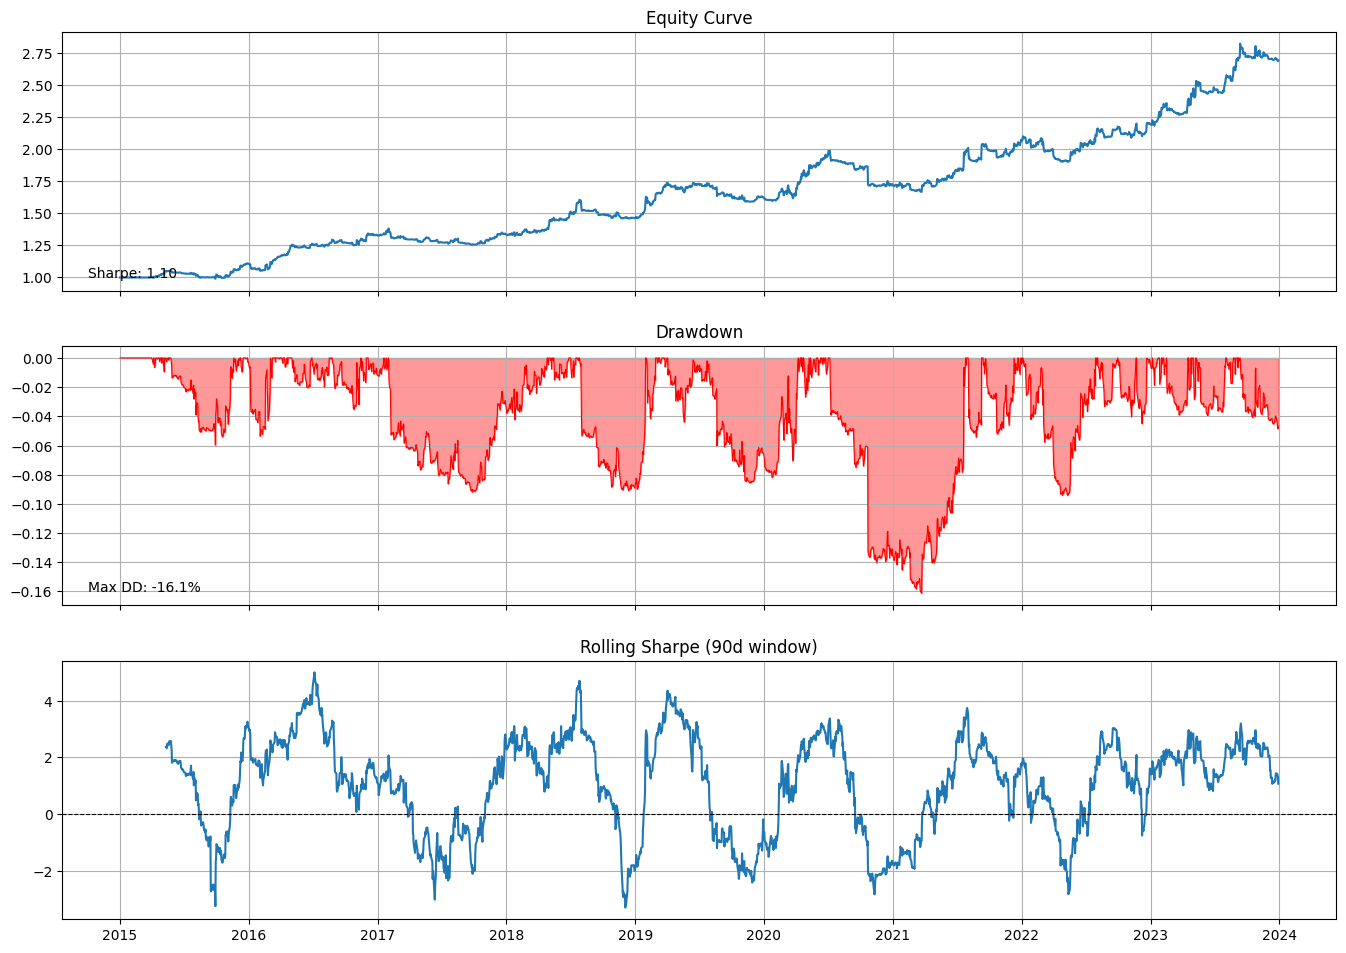

Study(name='residual_mean_reversion', steps=['base_signal', 'signal_filter', 'signal_filter', 'signal_filter', 'signal_filter', 'signal_filter', 'position_builder', 'position_scaler', 'position_scaler'], weighting=False, ran=True)

In [6]:
def demean_signal(signal, **cache):
    """Cross-sectionally demean the signal each day."""
    return signal.sub(signal.mean(axis=1), axis=0)


def equity_curve_regime_scale(positions, **cache):
    returns = cache["returns"]
    mask = cache.get("_tradeable_mask")
    
    if mask is None:
        mask = cache.get("_liquidity_mask")
    if mask is not None:
        returns = returns.where(mask)
        
    raw_ret = (positions.shift(1) * returns).sum(axis=1)
    equity = (1 + raw_ret).cumprod()
    equity_ma = equity.rolling(20).mean()
    scale = pd.Series(np.where(equity > equity_ma, 1.0, 0.25), index=equity.index)
    print("pipeline positions shape:", positions.shape)
    print("pipeline positions columns with any nonzero:", (positions != 0).any().sum())
    return positions.mul(scale.shift(1), axis=0)

def proportional_positions(signal, **cache):
    signal_z = signal.sub(signal.mean(axis=1), axis=0)
    signal_z = signal_z.div(signal_z.std(axis=1), axis=0)
    signal_z = signal_z.clip(-3, 3)
    signal_z = signal_z.sub(signal_z.mean(axis=1), axis=0)  # re-demean after clip
    positions = signal_z.div(signal_z.abs().sum(axis=1), axis=0)

    print("pipeline signal sample (last date):")
    last = signal.dropna(how='all').iloc[-1].dropna()
    print(last.to_dict())

    return positions

def mr_signal(**cache):
    return -cache["residual_returns"].rolling(5).mean().shift(1)
    
study = (
    Study(
        universe=universe,
        benchmark=benchmark,
        factors=factors,
        name="residual_mean_reversion",
    )
    .residualize_returns()  # produces residual_returns in cache
    .base_signal(mr_signal)
    .transform_signal(demean_signal)  # signal = signal.sub(signal.mean(axis=1), axis=0)
    .add_vol_filter(vol_window=5, quantile=0.6)
    .add_volume_zscore_filter(window=30, min_zscore_quantile=0.8)
    .add_momentum_context_filter(window=60, max_abs_quantile=0.7)
    .add_tradeable_constraint(qs.liquidity(top_n=250, window=60))
    # .build_long_short(n_long=25, n_short=25, rebalance_every=1)  # qs.build_long_short_positions(signal, 25, 25)
    .build_positions(proportional_positions)
    .rebalance(every=1)
    .scale_risk(equity_curve_regime_scale)  # 0.25x exposure when below 20-day equity MA
    .run()
)

study.report()

In [7]:
audit = study.audit()

In [10]:
audit

,step,stage,eligible_tickers,total_notna,nonzero_tickers,abs_sum_mean,net_sum_mean
0,base_signal,signal,461.0,1041399.0,NaN,NaN,NaN
1,demean_signal,signal,461.0,1041399.0,NaN,NaN,NaN
2,fn,signal,461.0,623484.0,NaN,NaN,NaN
3,fn,signal,461.0,98100.0,NaN,NaN,NaN
4,fn,signal,461.0,42286.0,NaN,NaN,NaN
5,liquidity(top_n=250),signal,353.0,21414.0,NaN,NaN,NaN
6,position_builder,position,NaN,NaN,461.0,1.0000,0.0
7,rebalance(every=1),position,NaN,NaN,461.0,1.0000,0.0
8,equity_curve_regime_scale,position,NaN,NaN,461.0,0.7235,0.0
